In [1]:
import tensorflow as tf
print(tf.__version__)
print(f"Keras: {tf.keras.__version__}")

2.19.0
Keras: 3.10.0


In [2]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
DATA_DIR ="/Users/praneeth/Documents/newplantvillage_data"


In [4]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 50396 images belonging to 34 classes.
Found 12583 images belonging to 34 classes.


In [5]:
class_names = list(train_gen.class_indices.keys())
print(class_names)


['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input

base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = Input(shape=(128, 128, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs, outputs)


In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [8]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)


/Users/praneeth/Documents/GitHub/crop2.0/server/venv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 192s 121ms/step - accuracy: 0.6666 - loss: 1.1676 - val_accuracy: 0.8980 - val_loss: 0.3156
Epoch 2/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 192s 122ms/step - accuracy: 0.8891 - loss: 0.3408 - val_accuracy: 0.9165 - val_loss: 0.2563
Epoch 3/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 186s 118ms/step - accuracy: 0.9094 - loss: 0.2710 - val_accuracy: 0.9189 - val_loss: 0.2428
Epoch 4/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 181s 115ms/step - accuracy: 0.9236 - loss: 0.2207 - val_accuracy: 0.9280 - val_loss: 0.2237
Epoch 5/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 193s 122ms/step - accuracy: 0.9268 - loss: 0.2122 - val_accuracy: 0.9250 - val_loss: 0.2286
Epoch 6/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 201s 128ms/step - accuracy: 0.9360 - loss: 0.1883 - val_accuracy: 0.9302 - val_loss: 0.2184
Epoch 7/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 191s 121ms/step - accuracy: 0.9431 - loss: 0.1669 - val_accuracy: 0.9247 - val_loss: 0.2337
Epoch 8/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 198s 125ms/step - ac

  Using cached matplotlib-3.10.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.58.4-cp310-cp310-macosx_10_9_universal2.whl.metadata (106 kB)
  Using cached kiwisolver-1.4.8-cp310-cp310-macosx_11_0_arm64.whl.metadata (6.2 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.3-cp310-cp310-macosx_11_0_arm64.whl (8.0 MB)
Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl (253 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.58.4-cp310-cp310-macosx_10_9_universal2.whl (2.7 MB)
Using cached kiwisolver-1.4.8-cp310-cp310-macosx_11_0_arm64.whl (65 kB)
Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may

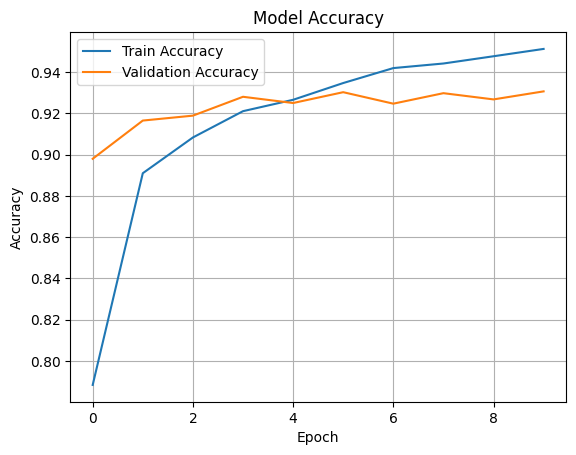

In [9]:
%pip install matplotlib
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


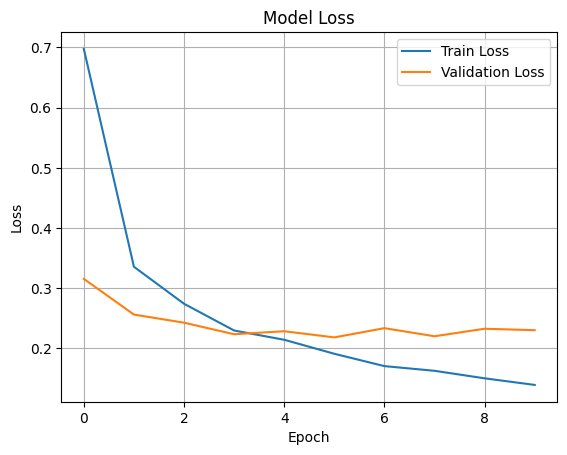

In [10]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [11]:
import numpy as np
from tensorflow.keras.preprocessing import image


In [12]:
img_path = '/Users/praneeth/Downloads/download (2).jpeg'
img = image.load_img(img_path, target_size=IMG_SIZE)  # Same as used in training, e.g., (128, 128)

img_array = image.img_to_array(img)
img_array = img_array / 255.0  # match rescale from ImageDataGenerator
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension


In [15]:
pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [16]:
print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}")


Predicted Class: Peach___Bacterial_spot
Confidence: 0.68


In [19]:
# Add this to your training script where you save the model

# Method 1: Save in multiple compatible formats
print("💾 Saving model in compatible formats...")


# Save in H5 format with specific options
model.save('AI_Model/plant_disease_model_v3.h5', save_format='h5', include_optimizer=False)
print("✅ Saved as H5 format")

# Save weights separately (most reliable)
model.save_weights('AI_Model/plant_disease_model_weights.weights.h5')
print("✅ Saved weights separately")

# Save model architecture as JSON
model_json = model.to_json()
with open('AI_Model/plant_disease_model_architecture.json', 'w') as json_file:
    json_file.write(model_json)
print("✅ Saved model architecture")

# Method 2: Save with compatibility options for newer TensorFlow
try:
    # This should work with TensorFlow 2.19+
    model.save('AI_Model/plant_disease_model_v3.keras', save_format='keras_v3')
    print("✅ Saved in Keras v3 format")
except:
    # Fallback
    model.save('AI_Model/plant_disease_model_v3_backup.h5')
    print("✅ Saved as backup H5")

print("🎉 Model saved in multiple formats for maximum compatibility!")

# Test loading immediately after saving
print("\n🔍 Testing model loading...")
try:
    test_model = tf.keras.models.load_model('AI_Model/plant_disease_model_v3.h5')
    print("✅ H5 model loads successfully")
except Exception as e:
    print(f"❌ H5 loading failed: {e}")

try:
    test_model = tf.keras.models.load_model('AI_Model/plant_disease_model_savedmodel')
    print("✅ SavedModel loads successfully")
except Exception as e:
    print(f"❌ SavedModel loading failed: {e}")

💾 Saving model in compatible formats...
✅ Saved as H5 format


✅ Saved weights separately
✅ Saved model architecture
✅ Saved in Keras v3 format
🎉 Model saved in multiple formats for maximum compatibility!

🔍 Testing model loading...


✅ H5 model loads successfully
❌ SavedModel loading failed: File format not supported: filepath=AI_Model/plant_disease_model_savedmodel. Keras 3 only supports V3 `.keras` files and legacy H5 format files (`.h5` extension). Note that the legacy SavedModel format is not supported by `load_model()` in Keras 3. In order to reload a TensorFlow SavedModel as an inference-only layer in Keras 3, use `keras.layers.TFSMLayer(AI_Model/plant_disease_model_savedmodel, call_endpoint='serving_default')` (note that your `call_endpoint` might have a different name).
